In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## 1. Environment Setup

In [2]:
import subprocess, sys
for pkg in [
    'typing_extensions==4.15.0 torch==2.7.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126',
    'transformers>=4.35.0', 
    'segmentation-models-pytorch', 
    'timm', 
    'einops', 
    'rasterio']:
    
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + pkg.split(), check=False)
    pass

print('Packages ready.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 191.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 218.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 198.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 80.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 95.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 128.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 131.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 133.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 MB 114.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 MB 134.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.3/201.3 MB 118.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.3/89.3 kB 102.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
# import subprocess, torch

# subprocess.run(['nvidia-smi'], check=False)

# print("\nPyTorch version  :", torch.__version__)
# print("CUDA built with    :", torch.version.cuda)
# print("GPU name           :", torch.cuda.get_device_name(0))
# print("Compute capability :", torch.cuda.get_device_capability(0))

In [4]:
import os, random, math, glob, json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchvision.models.segmentation import deeplabv3_resnet50
from transformers import SegformerForSemanticSegmentation
import torchvision.models as models
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import rasterio
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')

In [5]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [6]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Using device: cuda
GPU    : Tesla P100-PCIE-16GB
VRAM   : 17.1 GB


## 2. Dataset Preparation

In [7]:
# N_SAMPLES = 10 # For Coding

N_SAMPLES = None

In [8]:
DATA_ROOT = "/kaggle/input/datasets/deasadiqbal/private-data-1/patches"

IMAGES_DIR = os.path.join(DATA_ROOT, "Images")
LABELS_DIR = os.path.join(DATA_ROOT, "Labels")

image_paths = sorted(glob.glob(os.path.join(IMAGES_DIR, "*.tif")))
label_paths = sorted(glob.glob(os.path.join(LABELS_DIR, "*.tif")))

if N_SAMPLES:
    image_paths = image_paths[:N_SAMPLES]
    label_paths = label_paths[:N_SAMPLES]

print(f'Images found : {len(image_paths)}')
print(f'Labels found : {len(label_paths)}')

print('First 3 Sorted images:', [os.path.basename(p) for p in image_paths[:3]])
print('First 3 Sorted labels:', [os.path.basename(p) for p in label_paths[:3]])

Images found : 2400
Labels found : 2400
First 3 Sorted images: ['Image_0.tif', 'Image_1.tif', 'Image_10.tif']
First 3 Sorted labels: ['Label_0.tif', 'Label_1.tif', 'Label_10.tif']


In [9]:
def inspect_tif(path, name):
    with rasterio.open(path) as src:
        data = src.read()

        print(f"{name}: shape={data.shape} dtype={src.dtypes[0]}")

        for b in range(src.count):
            print(f'  band {b+1}: min={data[b].min()}  max={data[b].max()}')

    return data

img_data = inspect_tif(image_paths[0], "Image[0]")
print()
lbl_data = inspect_tif(label_paths[0], "Label[0]")

print('Unique label values:', np.unique(lbl_data))

Image[0]: shape=(3, 300, 300) dtype=uint8
  band 1: min=25  max=220
  band 2: min=19  max=176
  band 3: min=15  max=173

Label[0]: shape=(3, 300, 300) dtype=uint8
  band 1: min=0  max=255
  band 2: min=0  max=255
  band 3: min=0  max=255
Unique label values: [  0 255]


In [10]:
CLASS_NAMES = [
    'Impervious Surfaces',  # 0
    'Buildings',            # 1
    'Low Vegetation',       # 2
    'Trees',                # 3
    'Cars',                 # 4
    'Clutter/Background',   # 5
]

NUM_CLASSES  = len(CLASS_NAMES)
IGNORE_INDEX = 255

CLASS_PALETTE_RGB = [
    [255, 255, 255],  # 0 Impervious Surfaces
    [0,   0,   255],  # 1 Buildings
    [0,   255, 255],  # 2 Low Vegetation
    [0,   255, 0  ],  # 3 Trees
    [255, 255, 0  ],  # 4 Cars
    [255, 0,   0  ],  # 5 Clutter
]

CLASS_COLORS_NORM = [(r/255, g/255, b/255) for r, g, b in CLASS_PALETTE_RGB]

LABEL_FORMAT = 'auto'

In [11]:
print(f'{NUM_CLASSES} classes defined. LABEL_FORMAT={LABEL_FORMAT!r}')

6 classes defined. LABEL_FORMAT='auto'


In [12]:
IMG_SIZE = 256
IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD  = [0.229, 0.224, 0.225]

In [13]:
def rgb_to_index(arr):
    """HxWx3 uint8 → HxW uint8 class index."""
    out = np.full(arr.shape[:2], IGNORE_INDEX, dtype=np.uint8)
    for i, rgb in enumerate(CLASS_PALETTE_RGB):
        out[np.all(arr == rgb, axis=-1)] = i
    return out

In [14]:
def index_to_rgb(idx):
    """HxW int → HxWx3 uint8 colour map."""
    rgb = np.full((*idx.shape, 3), 128, dtype=np.uint8)
    for i, c in enumerate(CLASS_PALETTE_RGB):
        rgb[idx == i] = c
    return rgb

In [15]:
def load_tif_for_display(img_path, lbl_path, size=512):
    with rasterio.open(img_path) as src:
        d = src.read()[:3].astype(np.float32)
    d = d.transpose(1,2,0)
    for c in range(3):
        lo, hi = np.percentile(d[:,:,c], 2), np.percentile(d[:,:,c], 98)
        d[:,:,c] = np.clip((d[:,:,c] - lo)/(hi - lo + 1e-8), 0, 1)
    img_pil = Image.fromarray((d*255).astype(np.uint8)).resize((size, size))

    with rasterio.open(lbl_path) as src:
        ld = src.read()
        
    fmt = LABEL_FORMAT
    if fmt == 'auto':
        fmt = 'rgb' if ld.shape[0] >= 3 else 'index'
        
    if fmt == 'index':
        lbl_idx = id[0].astype(np.unit8)
    else:
        lbl_idx = rgb_to_index(ld[:3].transpose(1, 2, 0).astype(np.uint8))

    lbl_pil = Image.fromarray(lbl_idx).resize((size, size), Image.NEAREST)

    return np.array(img_pil), np.array(lbl_pil)

In [16]:
img_vis, lbl_vis = load_tif_for_display(image_paths[0], label_paths[0])

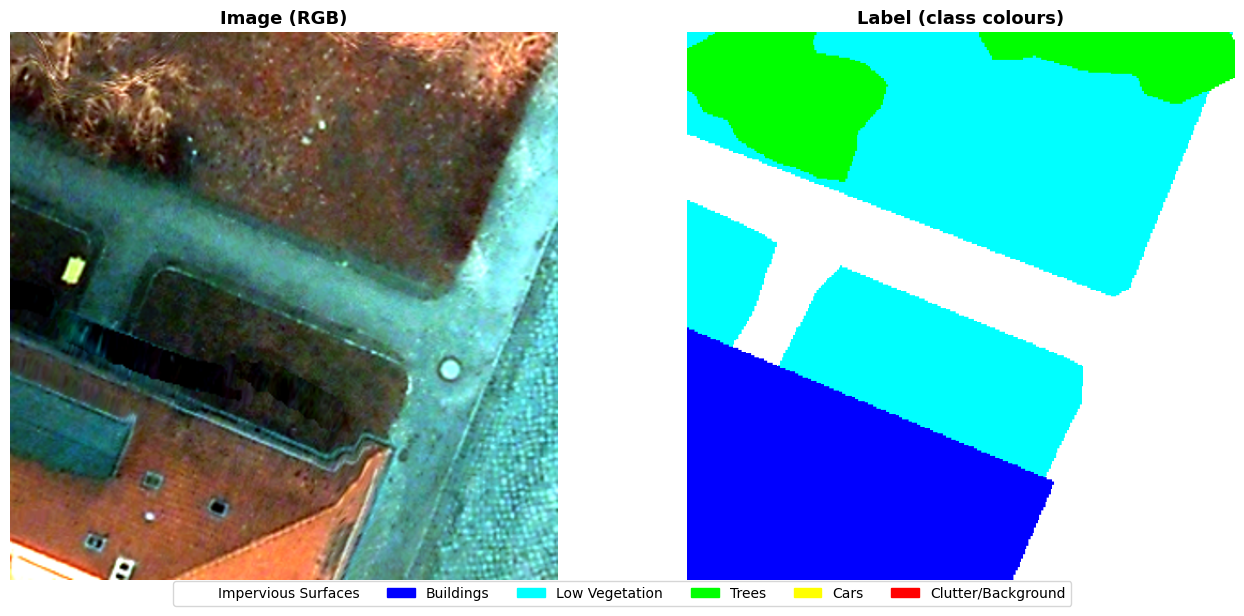

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(img_vis);
axes[0].set_title("Image (RGB)", fontsize=13, fontweight="bold")

axes[1].imshow(index_to_rgb(lbl_vis));
axes[1].set_title("Label (class colours)", fontsize=13, fontweight="bold")

for ax in axes: 
    ax.axis("off")

patches = [mpatches.Patch(color=c, label=n) for c, n in zip(CLASS_COLORS_NORM, CLASS_NAMES)]

fig.legend(handles=patches, loc="lower center", ncol=6, fontsize=10, bbox_to_anchor=(0.5,-0.03))

plt.tight_layout()
plt.savefig('/kaggle/working/data_sample.png', dpi=120, bbox_inches='tight')
plt.show()

In [18]:
print('Class distribution in first label:')
for i, name in enumerate(CLASS_NAMES):
    cnt = (lbl_vis == i ).sum()
    print(f'  [{i}] {name:<25}: {cnt:>6} px  ({100*cnt/lbl_vis.size:.1f}%)')

Class distribution in first label:
  [0] Impervious Surfaces      :  86498 px  (33.0%)
  [1] Buildings                :  54434 px  (20.8%)
  [2] Low Vegetation           :  93937 px  (35.8%)
  [3] Trees                    :  27275 px  (10.4%)
  [4] Cars                     :      0 px  (0.0%)
  [5] Clutter/Background       :      0 px  (0.0%)


## 3. Dataset & Point Sampler

In [19]:
def sample_point_labels(full_mask, point_density=0.05, strategy="random"):
    """
    Simulate point-level supervision from a dense mask.
    Returns (point_mask, binary_mask) — both [H,W].
    """
    H, W = full_mask.shape

    point_mask = torch.full_like(full_mask, IGNORE_INDEX)

    if strategy == "random":
        n_pts = max(1, int(H * W * point_density))
        flat_idx = torch.randperm(H * W)[:n_pts]
        point_mask.view(-1)[flat_idx] = full_mask.view(-1)[flat_idx]

    elif strategy == "class_balanced":
        for cls in range(NUM_CLASSES):
            px = (full_mask == cls).nonzero(as_tuple=False)
            if len(px) == 0:
                continue
            n_pts = max(1, int(len(px) * point_density))
            chosen = px[torch.randperm(len(px))[:n_pts]]
            point_mask[chosen[:,0], chosen[:,1]] = cls

    return point_mask, (point_mask != IGNORE_INDEX)

In [20]:
dummy = torch.randint(0, NUM_CLASSES, (256, 256))

pm, bm = sample_point_labels(dummy, 
                             0.05, 
                             "random")
print(f"Random     5%  → {bm.float().mean()*100:.2f}% labeled")

pm2, bm2 = sample_point_labels(dummy, 
                               0.05, 
                               "class_balanced")
print(f"Balanced   5%  → {bm.float().mean()*100:.2f}% labeled")

Random     5%  → 5.00% labeled
Balanced   5%  → 5.00% labeled


In [21]:
class PatchDataset(Dataset):
    def __init__(self, 
                 img_paths, 
                 lbl_paths, 
                 img_size=IMG_SIZE,
                 point_density=0.05, 
                 sampling_strategy='random',
                 label_format=LABEL_FORMAT, 
                 augment=True):
        
        assert len(img_paths) == len(lbl_paths)
        
        self.img_paths  = img_paths
        self.lbl_paths  = lbl_paths
        self.img_size   = img_size
        self.density    = point_density
        self.strategy   = sampling_strategy
        self.lbl_format = label_format
        self.augment    = augment
        self.mean = torch.tensor(IMG_MEAN).view(3,1,1)
        self.std  = torch.tensor(IMG_STD).view(3,1,1)

    def __len__(self): return len(self.img_paths)

    def _load_img(self, path):
        with rasterio.open(path) as src:
            d = src.read()
            
        d = (np.repeat(d, 3, 0) if d.shape[0]==1 else d[:3]).astype(np.float32)
        
        for c in range(3):
            lo, hi = np.percentile(d[c], 2), np.percentile(d[c], 98)
            if hi > lo: 
                d[c] = np.clip((d[c] - lo)/(hi - lo), 0, 1)
                
        t = torch.from_numpy(d)
        t = TF.resize(t, [self.img_size] * 2, TF.InterpolationMode.BILINEAR, antialias=True)
        
        return (t - self.mean) / self.std

    def _load_lbl(self, path):
        with rasterio.open(path) as src: 
            d = src.read()
            
        fmt = self.lbl_format
        
        if fmt == 'auto': 
            if d.shape[0] >= 3:
                fmt = 'rgb'
            else: 
                fmt = 'index'
            
         
        if fmt == 'index':
            arr = d[0].astype(np.uint8)
        else:
            arr = rgb_to_index(d[:3].transpose(1, 2, 0).astype(np.uint8))

        img_arr = (self.img_size,) * 2
                                              
        return np.array(Image.fromarray(arr).resize((self.img_size,)*2, Image.NEAREST), dtype=np.uint8)

    def _augment(self, img, lbl):
        if random.random() > 0.5:
            img = TF.hflip(img); lbl = TF.hflip(lbl.unsqueeze(0)).squeeze(0)
            
        if random.random() > 0.5:
            img = TF.vflip(img); lbl = TF.vflip(lbl.unsqueeze(0)).squeeze(0)
        
        angle = random.choice([0, 90, 180, 270])
        
        if angle:
            img = TF.rotate(img, angle)
            lbl = TF.rotate(lbl.unsqueeze(0), angle).squeeze(0)
        
        return img, lbl

    def __getitem__(self, idx):
        img  = self._load_img(self.img_paths[idx])
        lbl  = torch.from_numpy(self._load_lbl(self.lbl_paths[idx])).long()
        
        if self.augment: 
            img, lbl = self._augment(img, lbl)
        
        pm, bm = sample_point_labels(lbl, self.density, self.strategy)
        
        return {'image': img, 'full_mask': lbl, 'point_mask': pm, 'binary_mask': bm}

In [22]:
idx_all = list(range(len(image_paths)))
random.shuffle(idx_all)

cut = int(0.8 * len(idx_all))
tr_idx, va_idx = idx_all[:cut], idx_all[cut:]

In [23]:
TRAIN_IMG = [image_paths[i] for i in tr_idx]
TRAIN_LBL = [label_paths[i] for i in tr_idx]
VAL_IMG   = [image_paths[i] for i in va_idx]
VAL_LBL   = [label_paths[i] for i in va_idx]

print(f'Train: {len(TRAIN_IMG)}  Val: {len(VAL_IMG)}')

Train: 1920  Val: 480


In [24]:
s = PatchDataset(TRAIN_IMG, 
                 TRAIN_LBL, 
                 point_density=0.05)[0]

print(f"Image shape  : {s['image'].shape}")
print(f"Label shape  : {s['full_mask'].shape}")
print(f"Labeled px   : {s['binary_mask'].float().mean()*100:.2f}%")

Image shape  : torch.Size([3, 256, 256])
Label shape  : torch.Size([256, 256])
Labeled px   : 5.00%


In [25]:
BATCH_SIZE  = 16
NUM_WORKERS = 2

In [26]:
def make_loaders(point_density, strategy='random'):
    
    train = PatchDataset(TRAIN_IMG, 
                         TRAIN_LBL, 
                         point_density=point_density,
                         sampling_strategy=strategy, 
                         augment=True)
    
    valid = PatchDataset(VAL_IMG,   
                         VAL_LBL,   
                         point_density=1.0, 
                         augment=False)
    
    return (DataLoader(train, 
                       BATCH_SIZE, 
                       shuffle=True,  
                       num_workers=NUM_WORKERS,
                       pin_memory=True, 
                       drop_last=True),
            
            DataLoader(valid, 
                       BATCH_SIZE, 
                       shuffle=False, 
                       num_workers=NUM_WORKERS,
                       pin_memory=True))

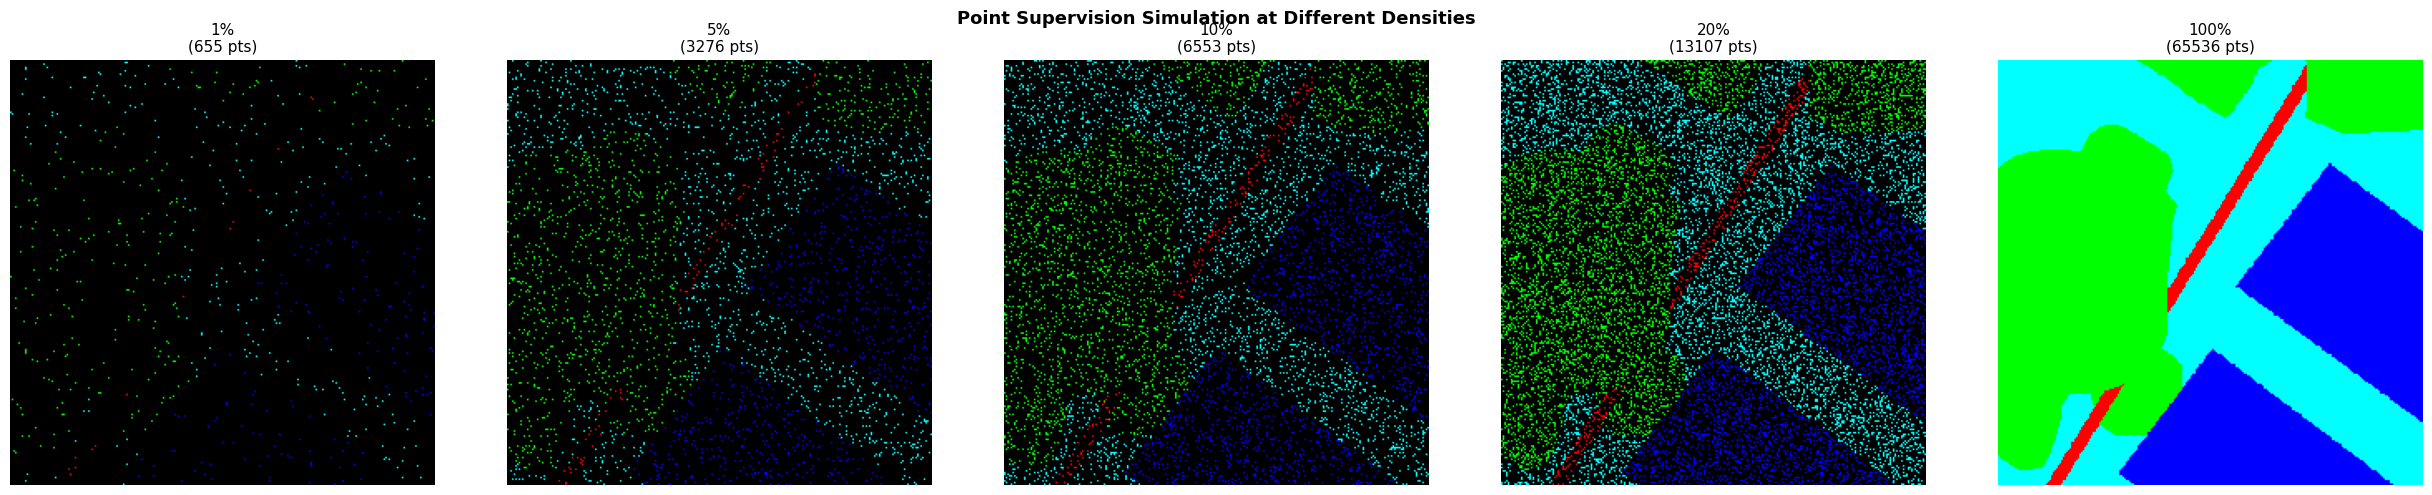

In [27]:
base = PatchDataset(TRAIN_IMG, 
                    TRAIN_LBL, 
                    point_density=1.0, 
                    augment=False)[0]

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle('Point Supervision Simulation at Different Densities', fontsize=13, fontweight='bold')

for ax, d in zip(axes, [0.01, 0.05, 0.10, 0.20, 1.00]):
    pm, bm = sample_point_labels(base['full_mask'], d, 'random')
    vis = np.zeros((*pm.shape, 3), dtype=np.uint8)
    
    for i, c in enumerate(CLASS_PALETTE_RGB): 
        vis[pm.numpy()==i] = c
        
    ax.imshow(vis)
    ax.set_title(f'{int(d*100)}%\n({bm.sum().item()} pts)', fontsize=11)
    ax.axis('off')
    
plt.tight_layout()
plt.savefig('/kaggle/working/point_densities.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Partial Cross-Entropy Loss

### Partial CE Loss
$$\text{pfCE} = \frac{\sum_{i} \left( \text{FocalLoss}(p_{t,i}) \cdot M_{\text{labeled},i} \right)}{\sum_{i} M_{\text{labeled},i}}$$

$$\text{FocalLoss}(p_t) = -(1 - p_t)^\gamma \log(p_t)$$

In [28]:
class PartialCrossEntropyLoss(nn.Module):
    def __init__(self, 
                 gamma=2.0, 
                 alpha=None, 
                 ignore_index=255):
        super().__init__()
        
        self.gamma = gamma
        self.ignore_index = ignore_index
        
        if alpha is not None:
            self.register_buffer('alpha', torch.tensor(alpha, dtype=torch.float32))
        else:
            self.alpha = None

    def forward(self, logits, targets):
        # logits  : [B, C, H, W]
        # targets : [B, H, W]  (IGNORE_INDEX = unlabeled)
        
        valid     = (targets != self.ignore_index)           # M_labeled
        n_labeled = valid.sum().clamp(min=1).float()
        safe_tgt  = targets.clone(); safe_tgt[~valid] = 0

        probs = F.softmax(logits, dim=1)
        p_t   = probs.gather(1, safe_tgt.unsqueeze(1)).squeeze(1).clamp(1e-8)
        ce    = -torch.log(p_t)
        
        if self.gamma > 0:
            ce = (1.0 - p_t) ** self.gamma * ce
        if self.alpha is not None:
            ce = self.alpha[safe_tgt] * ce
        
        return (ce * valid.float()).sum() / n_labeled

#### Unit tests for PartialCrossEntropyLoss

In [29]:
with torch.no_grad():
    B, C, H, W = 2, NUM_CLASSES, 32, 32
    lg = torch.randn(B, C, H, W); tg = torch.randint(0, C, (B, H, W))
    
    # γ=0 full sup == nn.CE
    pce = PartialCrossEntropyLoss(gamma=0)(lg, tg)
    ref = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)(lg, tg)
    assert abs(pce.item()-ref.item()) < 1e-4
    print(f'Full sup: pCE={pce:.4f} == nn.CE={ref:.4f}')
    
    # sparse
    sp, _ = sample_point_labels(tg[0], 0.05)
    print(f'Sparse 5%: pCE={PartialCrossEntropyLoss(gamma=2)(lg, torch.stack([sp,sp])):.4f}')
    
    # all ignored
    ign_tg = torch.full((B,H,W), IGNORE_INDEX)
    print(f'All ignored: pCE={PartialCrossEntropyLoss()(lg, ign_tg):.6f}  (~=0)')

print('pCE loss tests passed')

Full sup: pCE=2.1605 == nn.CE=2.1605
Sparse 5%: pCE=1.8095
All ignored: pCE=0.000000  (~=0)
pCE loss tests passed


## 5. Model Definitions

### DeepLabV3+ - ResNet-50

In [30]:
class DeepLabV3Plus(nn.Module):
    def __init__(self, 
                 num_classes=NUM_CLASSES, 
                 pretrained=True):
        super().__init__()
        
        w    = 'DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1' if pretrained else None
        
        base = deeplabv3_resnet50(weights=w)
        
        base.classifier[-1]     = nn.Conv2d(256, num_classes, 1)
        base.aux_classifier[-1] = nn.Conv2d(256, num_classes, 1)
        self.model = base

    def forward(self, x):
        H, W = x.shape[2:]
        out  = self.model(x)
        main = F.interpolate(out['out'], (H,W), mode='bilinear', align_corners=False)
        
        if self.training and 'aux' in out:
            aux = F.interpolate(out['aux'], (H,W), mode='bilinear', align_corners=False)
            return main, aux
        
        return main

### SegFormer-B2 — HuggingFace MiT-B2

In [31]:
class SegFormerB2(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        
        self.model = SegformerForSemanticSegmentation.from_pretrained(
            'nvidia/mit-b2',
            num_labels=num_classes,
            id2label={i: c for i,c in enumerate(CLASS_NAMES)},
            label2id={c: i for i,c in enumerate(CLASS_NAMES)},
            ignore_mismatched_sizes=True,
        )

    def forward(self, x):
        H, W   = x.shape[2:]
        logits = self.model(pixel_values=x).logits
        return F.interpolate(logits, (H,W), mode='bilinear', align_corners=False)

### UNet (ResNet-50)

In [32]:
class UNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, pretrained=True):
        super().__init__()

        resnet     = models.resnet50(weights='ResNet50_Weights.IMAGENET1K_V1' if pretrained else None)
        self.enc0  = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)   # 64  ch, 1/2
        self.pool  = resnet.maxpool                                         # 64  ch, 1/4
        self.enc1  = resnet.layer1                                          # 256  ch, 1/4
        self.enc2  = resnet.layer2                                          # 512  ch, 1/8
        self.enc3  = resnet.layer3                                          # 1024 ch, 1/16
        self.enc4  = resnet.layer4                                          # 2048 ch, 1/32

        def dec_block(in_ch, skip_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch + skip_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
                nn.Conv2d(out_ch,          out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            )

        self.up4 = nn.ConvTranspose2d(2048, 1024, 2, stride=2)
        self.db4 = dec_block(1024, 1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 512, 2, stride=2)
        self.db3 = dec_block(512, 512, 256)

        self.up2 = nn.ConvTranspose2d(256, 256, 2, stride=2)
        self.db2 = dec_block(256, 256, 128)

        self.seg_head = nn.Conv2d(128, num_classes, 1)

    def forward(self, x):
        H, W = x.shape[2:]
        e0   = self.enc0(x)              # 1/2
        e1   = self.enc1(self.pool(e0))  # 1/4
        e2   = self.enc2(e1)             # 1/8
        e3   = self.enc3(e2)             # 1/16
        e4   = self.enc4(e3)             # 1/32

        d = self.up4(e4)
        d = F.interpolate(d, size=e3.shape[2:], mode='bilinear', align_corners=False)
        d = self.db4(torch.cat([d, e3], dim=1))

        d = self.up3(d)
        d = F.interpolate(d, size=e2.shape[2:], mode='bilinear', align_corners=False)
        d = self.db3(torch.cat([d, e2], dim=1))

        d = self.up2(d)
        d = F.interpolate(d, size=e1.shape[2:], mode='bilinear', align_corners=False)
        d = self.db2(torch.cat([d, e1], dim=1))

        out = self.seg_head(d)
        return F.interpolate(out, (H, W), mode='bilinear', align_corners=False)

In [33]:
def count_params(m):
    t  = sum(p.numel() for p in m.parameters())
    tr = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return t, tr

In [34]:
tmp = DeepLabV3Plus()
t,tr = count_params(tmp)
print(f'DeepLabV3+   — {t/1e6:.1f}M total  {tr/1e6:.1f}M trainable')
del tmp

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:00<00:00, 241MB/s]


DeepLabV3+   — 42.0M total  42.0M trainable


In [35]:
tmp = SegFormerB2(); 
t,tr = count_params(tmp)
print(f'SegFormer-B2 — {t/1e6:.1f}M total  {tr/1e6:.1f}M trainable')
del tmp

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/99.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

SegFormer-B2 — 27.4M total  27.4M trainable


In [36]:
tmp = UNet()
t, tr = count_params(tmp)
print(f'UNet (ResNet-50) — {t/1e6:.1f}M total  {tr/1e6:.1f}M trainable')
del tmp

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


 78%|███████▊  | 76.0M/97.8M [00:00<00:00, 219MB/s]

model.safetensors:   0%|          | 0.00/98.9M [00:00<?, ?B/s]

100%|██████████| 97.8M/97.8M [00:00<00:00, 202MB/s]


UNet (ResNet-50) — 48.7M total  48.7M trainable


## 6. Training & Evaluation Utilities

In [37]:
class SegMetrics:
    def __init__(self, n): 
        self.n = n
        self.cm = np.zeros((n,n), dtype=np.int64)
        
    def update(self, pred, target):
        p = pred        
        if torch.is_tensor(pred):
            p = p.cpu().numpy() 
        p = p.ravel()

        t = target 
        if torch.is_tensor(target):
            t = t.cpu().numpy()
        t = t.ravel()
        
        m = t != IGNORE_INDEX
        
        np.add.at(self.cm, 
                  (t[m].clip(0, self.n - 1), 
                   p[m].clip(0, self.n - 1)), 
                  1)
        
    def compute(self):
        tp = np.diag(self.cm) 
        fp = self.cm.sum(0) - tp
        fn = self.cm.sum(1)-tp
        
        d  = (tp + fp + fn).astype(float)
        iou = np.where(d > 0, tp / d, np.nan)
        
        return {'mIoU': float(np.nanmean(iou)), 
                'iou_per_class': iou,
                'accuracy': tp.sum() / self.cm.sum() if self.cm.sum() > 0 else 0.0}
        
    def reset(self): 
        self.cm[:] = 0

In [38]:
def train_one_epoch(model, 
                    loader, 
                    optimizer, 
                    criterion, 
                    scaler, 
                    is_deeplab):
    model.train()
    total = 0.0
    
    for batch in tqdm(loader, desc='  train', leave=False):
        imgs = batch['image'].to(DEVICE)
        tgts = batch['point_mask'].to(DEVICE)
        optimizer.zero_grad()
        
        with torch.autocast('cuda', enabled=DEVICE.type=='cuda'):
            out = model(imgs)
            
            if is_deeplab and isinstance(out, tuple):
                loss = criterion(out[0], tgts) + 0.4 * criterion(out[1], tgts)
            else:
                if isinstance(out, tuple): 
                    out = out[0]
                    
                loss = criterion(out, tgts)
                
        scaler.scale(loss).backward() 
        scaler.step(optimizer)
        scaler.update()
        total += loss.item()
        
    return total / max(len(loader), 1)

In [39]:
@torch.no_grad()
def validate(model, loader):
    model.eval()
    metrics = SegMetrics(NUM_CLASSES)
    
    for batch in tqdm(loader, desc='validation', leave=False):
        out = model(batch['image'].to(DEVICE))
        if isinstance(out, tuple): 
            out = out[0]
        
        metrics.update(out.argmax(1).cpu(), batch['full_mask'])
    
    return metrics.compute()

In [40]:
NUM_EPOCHS   = 30       # increase to 80-100 for full results
LR_HEAD      = 6e-5
LR_BACKBONE  = 6e-6
WEIGHT_DECAY = 1e-4
WARMUP_EP    = 3
FOCAL_GAMMA  = 2.0
SAVE_DIR     = '/kaggle/working/checkpoints'
os.makedirs(SAVE_DIR, exist_ok=True)

In [41]:
def run_experiment(model_name, 
                   point_density, 
                   strategy='random', 
                   gamma=FOCAL_GAMMA):
    
    tag = f'{model_name}_d{int(point_density * 100):03d}'
    
    print(f'  Model    : {model_name}')
    print(f'  Density  : {point_density * 100:.0f}%  strategy={strategy}  gamma={gamma}')
    train_loader, val_loader = make_loaders(point_density, strategy)

    is_deeplab = (model_name == 'deeplabv3plus')
    if model_name == 'deeplabv3plus':
        model = DeepLabV3Plus(NUM_CLASSES).to(DEVICE)
        bb_params   = list(model.model.backbone.parameters())
        head_params = list(model.model.classifier.parameters()) + \
                      list(model.model.aux_classifier.parameters())
    
    elif model_name == 'segformer-b2':
        model = SegFormerB2(NUM_CLASSES).to(DEVICE)
        bb_params   = list(model.model.segformer.parameters())
        head_params = list(model.model.decode_head.parameters())
        
    else:  
        model = UNet(NUM_CLASSES).to(DEVICE)
        bb_params   = list(model.enc0.parameters()) + list(model.enc1.parameters()) + \
                      list(model.enc2.parameters()) + list(model.enc3.parameters()) + \
                      list(model.enc4.parameters())
        head_params = list(model.up4.parameters()) + list(model.db4.parameters()) + \
                      list(model.up3.parameters()) + list(model.db3.parameters()) + \
                      list(model.up2.parameters()) + list(model.db2.parameters()) + \
                      list(model.seg_head.parameters())

    criterion = PartialCrossEntropyLoss(gamma=gamma).to(DEVICE)
    
    optimizer = torch.optim.AdamW([
        {'params': bb_params,   'lr': LR_BACKBONE},
        {'params': head_params, 'lr': LR_HEAD},
    ], weight_decay=WEIGHT_DECAY)
    total_steps  = NUM_EPOCHS * len(train_loader)
    warmup_steps = WARMUP_EP  * len(train_loader)
    
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lambda s: (s / max(warmup_steps, 1)) if s < warmup_steps
                  else 0.5 * (1 + math.cos(math.pi * (s - warmup_steps) / max(total_steps - warmup_steps,1)))
    )
    scaler = torch.amp.GradScaler('cuda', enabled=DEVICE.type=='cuda')
    history = {'train_loss': [], 'val_miou': [], 'iou_per_class': []}
    best_miou, best_ckpt = 0.0, None
    
    for epoch in range(NUM_EPOCHS):
        loss = train_one_epoch(model, 
                               train_loader, 
                               optimizer, 
                               criterion, 
                               scaler, 
                               is_deeplab)
        
        scheduler.step(len(train_loader))
        res  = validate(model, val_loader)
        miou = res['mIoU']
        history['train_loss'].append(loss)
        history['val_miou'].append(miou)
        history['iou_per_class'].append(res['iou_per_class'].tolist())
        
        if miou > best_miou:
            best_miou = miou
            best_ckpt = f'{SAVE_DIR}/{tag}_best.pth'
            torch.save(model.state_dict(), best_ckpt)
            
        if (epoch+1) % 5 == 0:
            lr_now = optimizer.param_groups[1]['lr']
            
            print(f'  Epoch [{epoch + 1:3d}/{NUM_EPOCHS}]  Loss={loss:.4f}  '
                  f'mIoU={miou * 100:.2f}%  Best={best_miou * 100:.2f}%  lr={lr_now:.2e}')
            
    history.update(best_miou=best_miou, 
                   best_ckpt=best_ckpt,
                   final_iou_per_class=res['iou_per_class'],
                   final_accuracy=res['accuracy'])
    
    print(f'Done.  Best mIoU = {best_miou*100:.2f}%')
    
    return history

## Run A — DeepLabV3+ : Point Density Sweep
Five independent runs — **only** `point_density` differs across them.

In [42]:
# ══════════════════════════════════════════════════════════════════════════════
#  RUN A-1  |  DeepLabV3+  |  Point Density = 1%
# ══════════════════════════════════════════════════════════════════════════════
print('='*60)
print('  RUN A-1 : DeepLabV3+  |  Point Density = 1%')
print('='*60)
dlv3_1pct = run_experiment('deeplabv3plus', point_density=0.01)

  RUN A-1 : DeepLabV3+  |  Point Density = 1%
  Model    : deeplabv3plus
  Density  : 1%  strategy=random  gamma=2.0


  Epoch [  5/30]  Loss=0.6216  mIoU=52.16%  Best=52.16%  lr=2.00e-05


  Epoch [ 10/30]  Loss=0.4445  mIoU=60.64%  Best=60.64%  lr=2.00e-05


  Epoch [ 15/30]  Loss=0.3795  mIoU=63.14%  Best=63.39%  lr=2.00e-05


  Epoch [ 20/30]  Loss=0.3313  mIoU=65.14%  Best=65.72%  lr=2.00e-05


  Epoch [ 25/30]  Loss=0.2987  mIoU=67.01%  Best=67.01%  lr=2.00e-05


  Epoch [ 30/30]  Loss=0.2761  mIoU=67.83%  Best=68.02%  lr=2.00e-05
Done.  Best mIoU = 68.02%


In [43]:
# ══════════════════════════════════════════════════════════════════════════════
#  RUN A-2  |  DeepLabV3+  |  Point Density = 5%
# ══════════════════════════════════════════════════════════════════════════════
print('='*60)
print('  RUN A-2 : DeepLabV3+  |  Point Density = 5%')
print('='*60)
dlv3_5pct = run_experiment('deeplabv3plus', point_density=0.05)

  RUN A-2 : DeepLabV3+  |  Point Density = 5%
  Model    : deeplabv3plus
  Density  : 5%  strategy=random  gamma=2.0


  Epoch [  5/30]  Loss=0.6173  mIoU=52.73%  Best=52.73%  lr=2.00e-05


  Epoch [ 10/30]  Loss=0.4514  mIoU=60.60%  Best=60.60%  lr=2.00e-05


  Epoch [ 15/30]  Loss=0.3828  mIoU=63.97%  Best=63.97%  lr=2.00e-05


  Epoch [ 20/30]  Loss=0.3333  mIoU=66.56%  Best=66.56%  lr=2.00e-05


  Epoch [ 25/30]  Loss=0.3010  mIoU=67.20%  Best=67.41%  lr=2.00e-05


  Epoch [ 30/30]  Loss=0.2767  mIoU=68.25%  Best=68.25%  lr=2.00e-05
Done.  Best mIoU = 68.25%


In [44]:
# ══════════════════════════════════════════════════════════════════════════════
#  RUN A-3  |  DeepLabV3+  |  Point Density = 10%
# ══════════════════════════════════════════════════════════════════════════════
print('='*60)
print('  RUN A-3 : DeepLabV3+  |  Point Density = 10%')
print('='*60)
dlv3_10pct = run_experiment('deeplabv3plus', point_density=0.10)

  RUN A-3 : DeepLabV3+  |  Point Density = 10%
  Model    : deeplabv3plus
  Density  : 10%  strategy=random  gamma=2.0


  Epoch [  5/30]  Loss=0.6198  mIoU=54.56%  Best=54.56%  lr=2.00e-05


  Epoch [ 10/30]  Loss=0.4481  mIoU=61.97%  Best=61.97%  lr=2.00e-05


  Epoch [ 15/30]  Loss=0.3736  mIoU=64.45%  Best=64.45%  lr=2.00e-05


  Epoch [ 20/30]  Loss=0.3380  mIoU=66.82%  Best=66.82%  lr=2.00e-05


  Epoch [ 25/30]  Loss=0.2960  mIoU=68.12%  Best=68.12%  lr=2.00e-05


  Epoch [ 30/30]  Loss=0.2762  mIoU=68.61%  Best=68.84%  lr=2.00e-05
Done.  Best mIoU = 68.84%


In [45]:
# ══════════════════════════════════════════════════════════════════════════════
#  RUN A-4  |  DeepLabV3+  |  Point Density = 20%
# ══════════════════════════════════════════════════════════════════════════════
print('='*60)
print('  RUN A-4 : DeepLabV3+  |  Point Density = 20%')
print('='*60)
dlv3_20pct = run_experiment('deeplabv3plus', point_density=0.20)

  RUN A-4 : DeepLabV3+  |  Point Density = 20%
  Model    : deeplabv3plus
  Density  : 20%  strategy=random  gamma=2.0


  Epoch [  5/30]  Loss=0.6294  mIoU=53.39%  Best=53.39%  lr=2.00e-05


  Epoch [ 10/30]  Loss=0.4442  mIoU=61.59%  Best=61.59%  lr=2.00e-05


  Epoch [ 15/30]  Loss=0.3758  mIoU=63.82%  Best=63.82%  lr=2.00e-05


  Epoch [ 20/30]  Loss=0.3369  mIoU=66.49%  Best=66.49%  lr=2.00e-05


  Epoch [ 25/30]  Loss=0.3012  mIoU=67.67%  Best=67.67%  lr=2.00e-05


  Epoch [ 30/30]  Loss=0.2789  mIoU=68.51%  Best=68.51%  lr=2.00e-05
Done.  Best mIoU = 68.51%


In [46]:
# ══════════════════════════════════════════════════════════════════════════════
#  RUN A-5  |  DeepLabV3+  |  Full Supervision  (100% — upper-bound baseline)
# ══════════════════════════════════════════════════════════════════════════════
print('='*60)
print('  RUN A-5 : DeepLabV3+  |  Full Supervision (100%)')
print('='*60)
dlv3_full = run_experiment('deeplabv3plus', point_density=1.00)

  RUN A-5 : DeepLabV3+  |  Full Supervision (100%)
  Model    : deeplabv3plus
  Density  : 100%  strategy=random  gamma=2.0


  Epoch [  5/30]  Loss=0.6308  mIoU=53.19%  Best=53.19%  lr=2.00e-05


  Epoch [ 10/30]  Loss=0.4478  mIoU=60.41%  Best=60.41%  lr=2.00e-05


  Epoch [ 15/30]  Loss=0.3784  mIoU=64.46%  Best=64.46%  lr=2.00e-05


  Epoch [ 20/30]  Loss=0.3297  mIoU=66.68%  Best=66.68%  lr=2.00e-05


  Epoch [ 25/30]  Loss=0.3047  mIoU=67.46%  Best=67.50%  lr=2.00e-05


  Epoch [ 30/30]  Loss=0.2809  mIoU=68.79%  Best=68.90%  lr=2.00e-05
Done.  Best mIoU = 68.90%


In [47]:
RUN_A = {
    'deeplabv3plus_1%'         : dlv3_1pct,
    'deeplabv3plus_5%'         : dlv3_5pct,
    'deeplabv3plus_10%'        : dlv3_10pct,
    'deeplabv3plus_20%'        :  dlv3_20pct,
    'deeplabv3plus_100% (Full)':  dlv3_full,
}

print('\nRun A — DeepLabV3+ Summary')
print(f'{"Density":<30} {"Best mIoU":>10} {"Accuracy":>10}')
print('-'*60)
for lbl, h in RUN_A.items():
    print(f'{lbl:<28} {h["best_miou"]*100:>9.2f}%  {h["final_accuracy"]*100:>9.2f}%')


Run A — DeepLabV3+ Summary
Density                         Best mIoU   Accuracy
------------------------------------------------------------
deeplabv3plus_1%                 68.02%      84.15%
deeplabv3plus_5%                 68.25%      84.62%
deeplabv3plus_10%                68.84%      84.80%
deeplabv3plus_20%                68.51%      84.75%
deeplabv3plus_100% (Full)        68.90%      84.69%


In [48]:
def plot_miou_vs_density(run_data, run_name="DeepLabV3+", save_path=None):
    """
    Plot Bar chart of best mIoU vs density
    Plot Line chart of validation mIoU over epochs
    """

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'RUN {run_name} : Effect of Point Density on mIoU',
                 fontsize=14, fontweight='bold')

    labels = list(run_data.keys())
    mious  = [run_data[k]['best_miou'] * 100 for k in labels]
    colors = plt.cm.Blues(np.linspace(0.35, 0.9, len(labels)))

    ax = axes[0]
    bars = ax.bar(labels, mious, color=colors, edgecolor='black', linewidth=0.7)
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=10)
    ax.set_xlabel('Point Label Density', fontsize=12)
    ax.tick_params(axis='x', labelrotation=45)
    ax.set_ylabel('Best Validation mIoU (%)', fontsize=12)
    ax.set_title(f'mIoU vs Density ({run_name})', fontsize=12)
    ax.set_ylim(0, max(mious) * 1.15)
    ax.grid(axis='y', alpha=0.3)

    ax2 = axes[1]
    for lbl, h in run_data.items():
        ax2.plot(h['val_miou'], label=lbl, linewidth=2)

    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Validation mIoU')
    ax2.set_title(f'Training Curves ({run_name})')
    ax2.legend(fontsize=10)
    ax2.grid(alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.show()

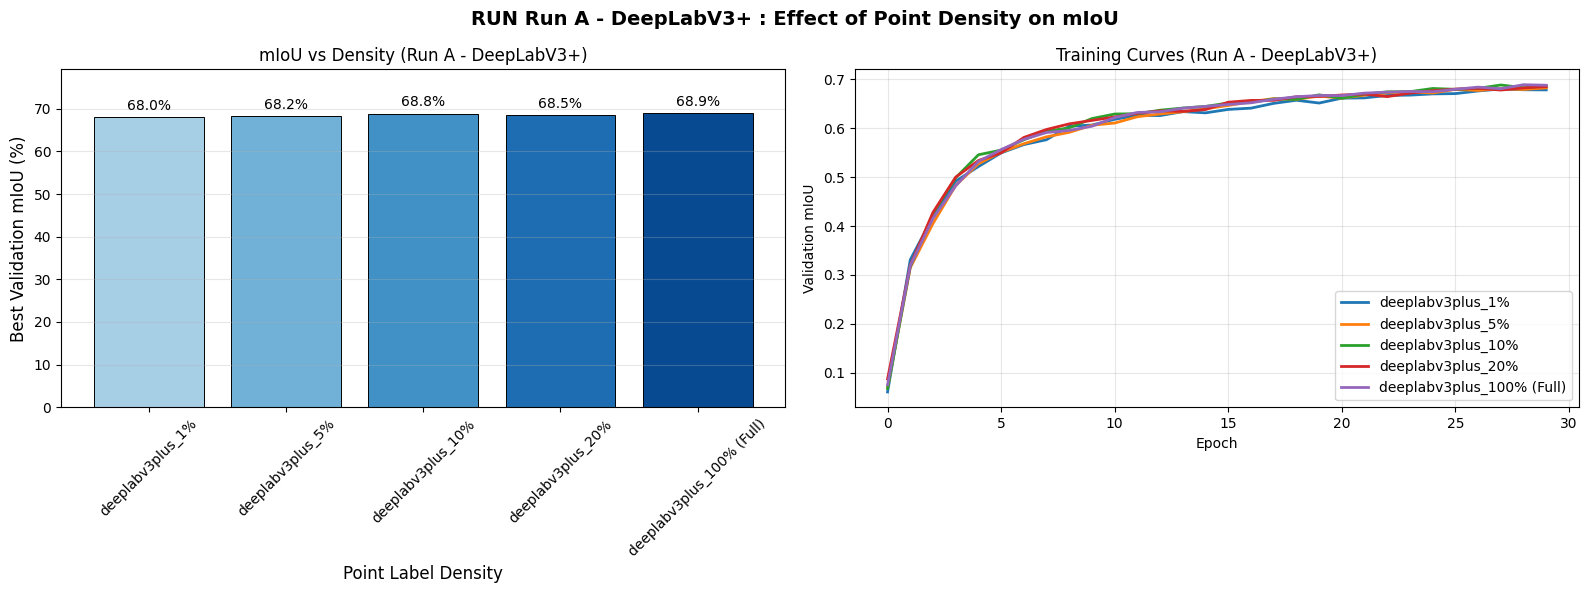

In [49]:
plot_miou_vs_density(RUN_A, 
                     run_name="Run A - DeepLabV3+",
                     save_path="/kaggle/working/run_a_deeplabb3plus_per_density.png")

In [50]:
def plot_per_class_iou(run_data, class_names, run_name="DeepLabV3+", save_path=None):
    fig, ax = plt.subplots(figsize=(14, 6))

    num_classes = len(class_names)
    x = np.arange(num_classes)
    w = 0.75 / len(run_data)

    for i, (lbl, h) in enumerate(run_data.items()):
        iou = np.array(h['final_iou_per_class']) * 100
        ax.bar(x + (i - len(run_data)/2 + 0.5)*w, iou, w,
               label=lbl, alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(class_names, fontsize=11)
    ax.set_ylabel('IoU (%)')
    ax.set_title(f'Per-Class IoU by Density — ({run_name})',
                 fontsize=13, fontweight='bold')

    ax.legend(title='Density', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.show()


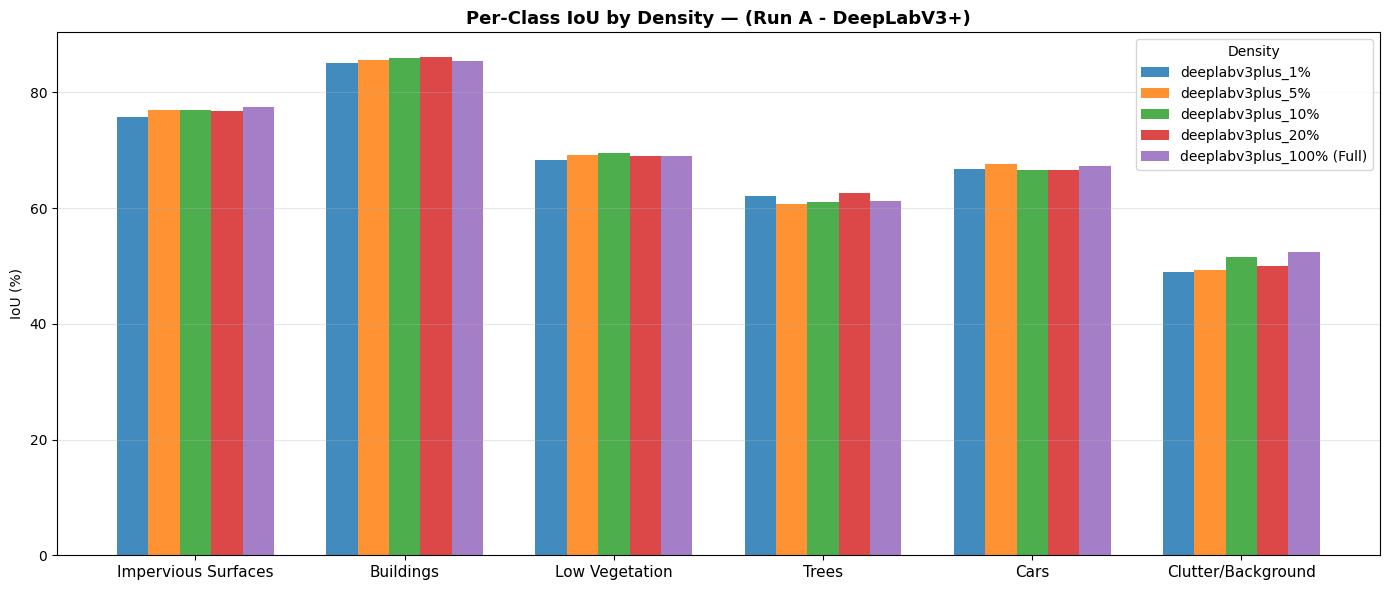

In [51]:
plot_per_class_iou(RUN_A,
                   CLASS_NAMES,
                   run_name="Run A - DeepLabV3+",
                   save_path="/kaggle/working/run_a_deeplabb3plus_per_class.png")

## Run B — SegFormer-B2 : Point Density Sweep
Five independent runs — **only** `point_density` differs across them.

In [52]:
# ══════════════════════════════════════════════════════════════════════════════
#  RUN B-1  |  SegFormer-B2  |  Point Density = 1%
# ══════════════════════════════════════════════════════════════════════════════
print('='*60)
print('  RUN B-1 : SegFormer-B2  |  Point Density = 1%')
print('='*60)
sf_1pct = run_experiment('segformer-b2', point_density=0.01)

  RUN B-1 : SegFormer-B2  |  Point Density = 1%
  Model    : segformer-b2
  Density  : 1%  strategy=random  gamma=2.0


Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

  Epoch [  5/30]  Loss=0.2981  mIoU=63.29%  Best=63.29%  lr=2.00e-05


  Epoch [ 10/30]  Loss=0.2178  mIoU=68.29%  Best=68.29%  lr=2.00e-05


  Epoch [ 15/30]  Loss=0.1897  mIoU=70.13%  Best=70.13%  lr=2.00e-05


  Epoch [ 20/30]  Loss=0.1687  mIoU=71.29%  Best=71.29%  lr=2.00e-05


  Epoch [ 25/30]  Loss=0.1551  mIoU=71.97%  Best=71.97%  lr=2.00e-05


  Epoch [ 30/30]  Loss=0.1448  mIoU=72.15%  Best=72.32%  lr=2.00e-05
Done.  Best mIoU = 72.32%


In [53]:
# ══════════════════════════════════════════════════════════════════════════════
#  RUN B-2  |  SegFormer-B2  |  Point Density = 5%
# ══════════════════════════════════════════════════════════════════════════════
print('='*60)
print('  RUN B-2 : SegFormer-B2  |  Point Density = 5%')
print('='*60)
sf_5pct = run_experiment('segformer-b2', point_density=0.05)

  RUN B-2 : SegFormer-B2  |  Point Density = 5%
  Model    : segformer-b2
  Density  : 5%  strategy=random  gamma=2.0


Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

  Epoch [  5/30]  Loss=0.2965  mIoU=63.06%  Best=63.06%  lr=2.00e-05


  Epoch [ 10/30]  Loss=0.2179  mIoU=68.13%  Best=68.13%  lr=2.00e-05


  Epoch [ 15/30]  Loss=0.1884  mIoU=70.50%  Best=70.50%  lr=2.00e-05


  Epoch [ 20/30]  Loss=0.1712  mIoU=71.17%  Best=71.40%  lr=2.00e-05


  Epoch [ 25/30]  Loss=0.1529  mIoU=72.22%  Best=72.22%  lr=2.00e-05


  Epoch [ 30/30]  Loss=0.1452  mIoU=72.44%  Best=72.59%  lr=2.00e-05
Done.  Best mIoU = 72.59%


In [54]:
# ══════════════════════════════════════════════════════════════════════════════
#  RUN B-3  |  SegFormer-B2  |  Point Density = 10%
# ══════════════════════════════════════════════════════════════════════════════
print('='*60)
print('  RUN B-3 : SegFormer-B2  |  Point Density = 10%')
print('='*60)
sf_10pct = run_experiment('segformer-b2', point_density=0.1)

  RUN B-3 : SegFormer-B2  |  Point Density = 10%
  Model    : segformer-b2
  Density  : 10%  strategy=random  gamma=2.0


Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

  Epoch [  5/30]  Loss=0.2958  mIoU=63.31%  Best=63.31%  lr=2.00e-05


  Epoch [ 10/30]  Loss=0.2213  mIoU=68.21%  Best=68.21%  lr=2.00e-05


  Epoch [ 15/30]  Loss=0.1865  mIoU=69.95%  Best=69.95%  lr=2.00e-05


  Epoch [ 20/30]  Loss=0.1667  mIoU=71.14%  Best=71.14%  lr=2.00e-05


  Epoch [ 25/30]  Loss=0.1573  mIoU=71.73%  Best=71.82%  lr=2.00e-05


  Epoch [ 30/30]  Loss=0.1429  mIoU=72.55%  Best=72.55%  lr=2.00e-05
Done.  Best mIoU = 72.55%


In [55]:
# ══════════════════════════════════════════════════════════════════════════════
#  RUN B-4  |  SegFormer-B2  |  Point Density = 20%
# ══════════════════════════════════════════════════════════════════════════════
print('='*60)
print('  RUN B-4 : SegFormer-B2  |  Point Density = 20%')
print('='*60)
sf_20pct = run_experiment('segformer-b2', point_density=0.2)

  RUN B-4 : SegFormer-B2  |  Point Density = 20%
  Model    : segformer-b2
  Density  : 20%  strategy=random  gamma=2.0


Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

  Epoch [  5/30]  Loss=0.2920  mIoU=63.14%  Best=63.14%  lr=2.00e-05


  Epoch [ 10/30]  Loss=0.2170  mIoU=68.33%  Best=68.33%  lr=2.00e-05


  Epoch [ 15/30]  Loss=0.1866  mIoU=70.34%  Best=70.34%  lr=2.00e-05


  Epoch [ 20/30]  Loss=0.1689  mIoU=70.99%  Best=70.99%  lr=2.00e-05


  Epoch [ 25/30]  Loss=0.1537  mIoU=71.85%  Best=71.85%  lr=2.00e-05


  Epoch [ 30/30]  Loss=0.1445  mIoU=71.18%  Best=72.36%  lr=2.00e-05
Done.  Best mIoU = 72.36%


In [56]:
# ══════════════════════════════════════════════════════════════════════════════
#  RUN B-5  |  SegFormer-B2  |  Full Supervision  (100% — upper-bound baseline)
# ══════════════════════════════════════════════════════════════════════════════
print('='*60)
print('  RUN B-5 : SegFormer-B2  |  Full Supervision (100%)')
print('='*60)
sf_full = run_experiment('segformer-b2', point_density=1.00)

  RUN B-5 : SegFormer-B2  |  Full Supervision (100%)
  Model    : segformer-b2
  Density  : 100%  strategy=random  gamma=2.0


Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

  Epoch [  5/30]  Loss=0.2961  mIoU=63.31%  Best=63.31%  lr=2.00e-05


  Epoch [ 10/30]  Loss=0.2183  mIoU=68.41%  Best=68.41%  lr=2.00e-05


  Epoch [ 15/30]  Loss=0.1881  mIoU=70.30%  Best=70.30%  lr=2.00e-05


  Epoch [ 20/30]  Loss=0.1709  mIoU=71.35%  Best=71.35%  lr=2.00e-05


  Epoch [ 25/30]  Loss=0.1541  mIoU=71.86%  Best=71.97%  lr=2.00e-05


  Epoch [ 30/30]  Loss=0.1450  mIoU=72.49%  Best=72.49%  lr=2.00e-05
Done.  Best mIoU = 72.49%


In [57]:
RUN_B = {
    'segformer-b2_1%'         : sf_1pct,
    'segformer-b2_5%'         : sf_5pct,
    'segformer-b2_10%'        : sf_10pct,
    'segformer-b2_20%'        : sf_20pct,
    'segformer-b2_100% (Full)': sf_full,
}

print('\nRun B — SegFormer-B2 Summary')
print(f'{"Density":<30} {"Best mIoU":>10} {"Accuracy":>10}')
print('-'*60)
for lbl, h in RUN_B.items():
    print(f'{lbl:<28} {h["best_miou"]*100:>9.2f}%  {h["final_accuracy"]*100:>9.2f}%')


Run B — SegFormer-B2 Summary
Density                         Best mIoU   Accuracy
------------------------------------------------------------
segformer-b2_1%                  72.32%      86.65%
segformer-b2_5%                  72.59%      86.75%
segformer-b2_10%                 72.55%      86.71%
segformer-b2_20%                 72.36%      86.14%
segformer-b2_100% (Full)         72.49%      86.78%


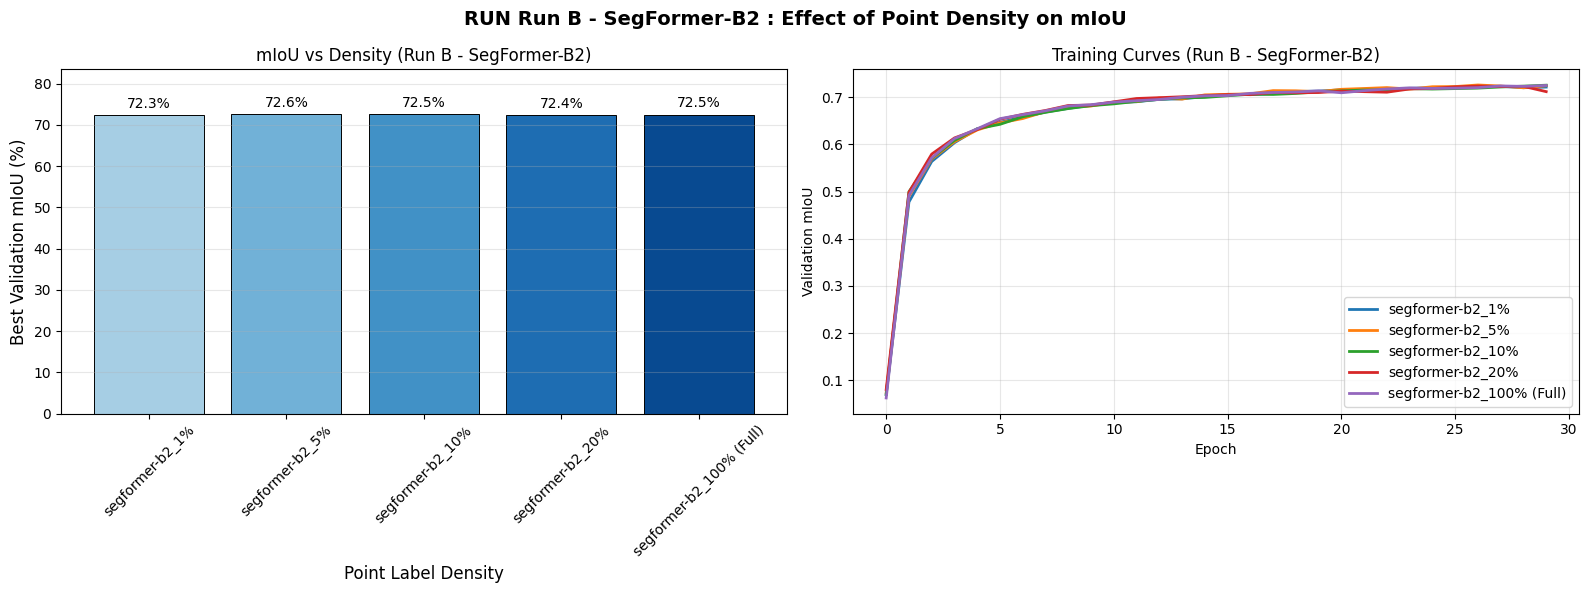

In [58]:
plot_miou_vs_density(RUN_B, 
                     run_name="Run B - SegFormer-B2",
                     save_path="/kaggle/working/run_b_segformer-b2_per_density.png")

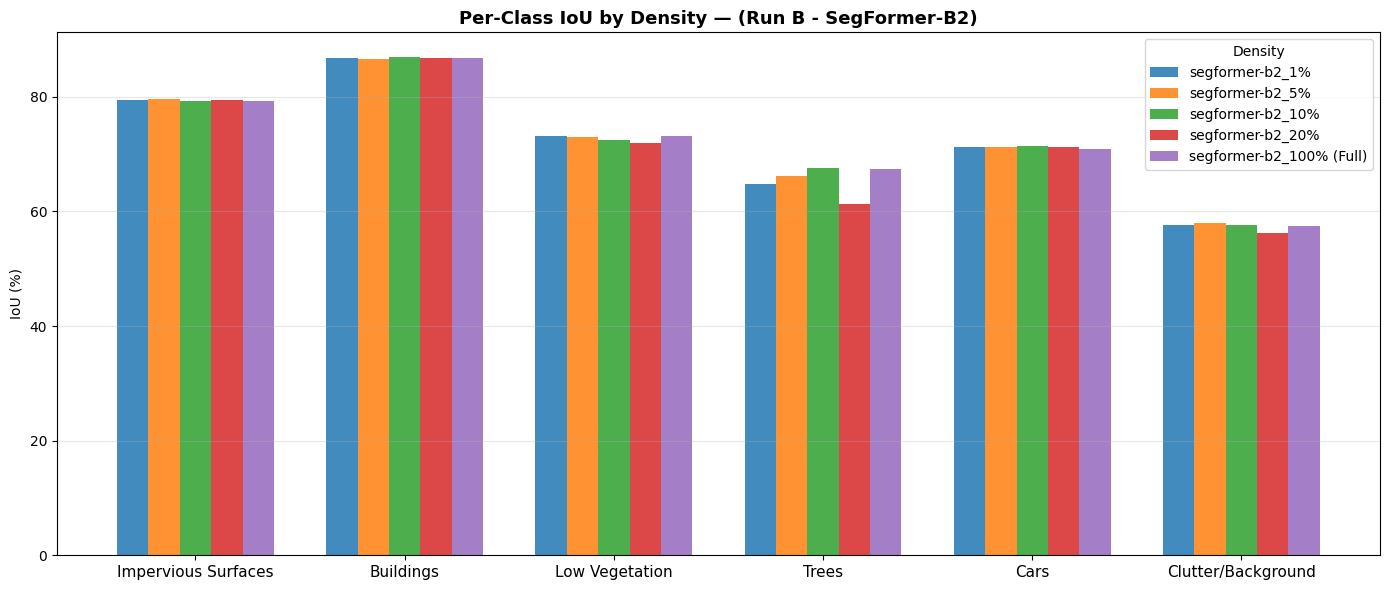

In [59]:
plot_per_class_iou(RUN_B,
                   CLASS_NAMES,
                   run_name="Run B - SegFormer-B2",
                   save_path="/kaggle/working/run_b_segformer-b2_per_class.png")

## Run C — Unet-(ResNet-50) : Point Density Sweep
Five independent runs — **only** `point_density` differs across them.

In [60]:
# ══════════════════════════════════════════════════════════════════════════════
#  RUN C-1  |  UNet  |  Point Density = 1%
# ══════════════════════════════════════════════════════════════════════════════
print('='*60)
print('  RUN C-1 : UNet  |  Point Density = 1%')
print('='*60)
unet_1pct = run_experiment('unet', point_density=0.01)

  RUN C-1 : UNet  |  Point Density = 1%
  Model    : unet
  Density  : 1%  strategy=random  gamma=2.0


  Epoch [  5/30]  Loss=0.3183  mIoU=64.90%  Best=64.90%  lr=2.00e-05


  Epoch [ 10/30]  Loss=0.2192  mIoU=68.13%  Best=68.13%  lr=2.00e-05


  Epoch [ 15/30]  Loss=0.1763  mIoU=69.23%  Best=69.27%  lr=2.00e-05


  Epoch [ 20/30]  Loss=0.1520  mIoU=70.71%  Best=70.71%  lr=2.00e-05


  Epoch [ 25/30]  Loss=0.1371  mIoU=71.07%  Best=71.07%  lr=2.00e-05


  Epoch [ 30/30]  Loss=0.1156  mIoU=71.18%  Best=71.21%  lr=2.00e-05
Done.  Best mIoU = 71.21%


In [61]:
# ══════════════════════════════════════════════════════════════════════════════
#  RUN C-2  |  UNet  |  Point Density = 5%
# ══════════════════════════════════════════════════════════════════════════════
print('='*60)
print('  RUN C-2 : UNet  |  Point Density = 5%')
print('='*60)
unet_5pct = run_experiment('unet', point_density=0.05)

  RUN C-2 : UNet  |  Point Density = 5%
  Model    : unet
  Density  : 5%  strategy=random  gamma=2.0


  Epoch [  5/30]  Loss=0.2850  mIoU=64.78%  Best=64.78%  lr=2.00e-05


  Epoch [ 10/30]  Loss=0.2086  mIoU=67.46%  Best=67.81%  lr=2.00e-05


  Epoch [ 15/30]  Loss=0.1757  mIoU=70.31%  Best=70.31%  lr=2.00e-05


  Epoch [ 20/30]  Loss=0.1427  mIoU=70.16%  Best=70.88%  lr=2.00e-05


  Epoch [ 25/30]  Loss=0.1316  mIoU=70.78%  Best=71.16%  lr=2.00e-05


  Epoch [ 30/30]  Loss=0.1104  mIoU=70.46%  Best=71.16%  lr=2.00e-05
Done.  Best mIoU = 71.16%


In [62]:
# ══════════════════════════════════════════════════════════════════════════════
#  RUN C-3  |  UNet  |  Point Density = 10%
# ══════════════════════════════════════════════════════════════════════════════
print('='*60)
print('  RUN C-3 : UNet  |  Point Density = 10%')
print('='*60)
unet_10pct = run_experiment('unet', point_density=0.10)

  RUN C-3 : UNet  |  Point Density = 10%
  Model    : unet
  Density  : 10%  strategy=random  gamma=2.0


  Epoch [  5/30]  Loss=0.3106  mIoU=65.15%  Best=65.15%  lr=2.00e-05


  Epoch [ 10/30]  Loss=0.2207  mIoU=67.14%  Best=67.54%  lr=2.00e-05


  Epoch [ 15/30]  Loss=0.1763  mIoU=69.88%  Best=69.90%  lr=2.00e-05


  Epoch [ 20/30]  Loss=0.1485  mIoU=70.51%  Best=70.51%  lr=2.00e-05


  Epoch [ 25/30]  Loss=0.1264  mIoU=70.86%  Best=71.12%  lr=2.00e-05


  Epoch [ 30/30]  Loss=0.1100  mIoU=70.23%  Best=71.12%  lr=2.00e-05
Done.  Best mIoU = 71.12%


In [63]:
# ══════════════════════════════════════════════════════════════════════════════
#  RUN C-4  |  UNet  |  Point Density = 20%
# ══════════════════════════════════════════════════════════════════════════════
print('='*60)
print('  RUN C-4 : UNet  |  Point Density = 20%')
print('='*60)
unet_20pct = run_experiment('unet', point_density=0.20)

  RUN C-4 : UNet  |  Point Density = 20%
  Model    : unet
  Density  : 20%  strategy=random  gamma=2.0


  Epoch [  5/30]  Loss=0.3048  mIoU=64.80%  Best=64.80%  lr=2.00e-05


  Epoch [ 10/30]  Loss=0.2237  mIoU=67.92%  Best=68.62%  lr=2.00e-05


  Epoch [ 15/30]  Loss=0.1772  mIoU=69.21%  Best=69.81%  lr=2.00e-05


  Epoch [ 20/30]  Loss=0.1470  mIoU=70.72%  Best=70.72%  lr=2.00e-05


  Epoch [ 25/30]  Loss=0.1306  mIoU=70.58%  Best=71.33%  lr=2.00e-05


  Epoch [ 30/30]  Loss=0.1148  mIoU=70.58%  Best=71.33%  lr=2.00e-05
Done.  Best mIoU = 71.33%


In [64]:
# ══════════════════════════════════════════════════════════════════════════════
#  RUN C-5  |  UNet  |  Full Supervision  (100% — upper-bound baseline)
# ══════════════════════════════════════════════════════════════════════════════
print('='*60)
print('  RUN C-5 : UNet  |  Full Supervision (100%)')
print('='*60)
unet_full = run_experiment('unet', point_density=1.00)

  RUN C-5 : UNet  |  Full Supervision (100%)
  Model    : unet
  Density  : 100%  strategy=random  gamma=2.0


  Epoch [  5/30]  Loss=0.2827  mIoU=62.55%  Best=62.99%  lr=2.00e-05


  Epoch [ 10/30]  Loss=0.2083  mIoU=68.69%  Best=68.69%  lr=2.00e-05


  Epoch [ 15/30]  Loss=0.1730  mIoU=70.23%  Best=70.65%  lr=2.00e-05


  Epoch [ 20/30]  Loss=0.1431  mIoU=69.81%  Best=70.65%  lr=2.00e-05


  Epoch [ 25/30]  Loss=0.1215  mIoU=71.41%  Best=71.58%  lr=2.00e-05


  Epoch [ 30/30]  Loss=0.1151  mIoU=68.97%  Best=71.58%  lr=2.00e-05
Done.  Best mIoU = 71.58%


In [65]:
RUN_C = {
    'unet_1%'          : unet_1pct,
    'unet_5%'          : unet_5pct,
    'unet_10%'         : unet_10pct,
    'unet_20%'         : unet_20pct,
    'unet_100% (Full)' : unet_full,
}

print('\nRun C — UNet Summary')
print(f'{"Density":<30} {"Best mIoU":>10} {"Accuracy":>10}')
print('-'*60)
for lbl, h in RUN_C.items():
    print(f'{lbl:<28} {h["best_miou"]*100:>9.2f}%  {h["final_accuracy"]*100:>9.2f}%')


Run C — UNet Summary
Density                         Best mIoU   Accuracy
------------------------------------------------------------
unet_1%                          71.21%      85.84%
unet_5%                          71.16%      85.17%
unet_10%                         71.12%      85.37%
unet_20%                         71.33%      85.33%
unet_100% (Full)                 71.58%      84.78%


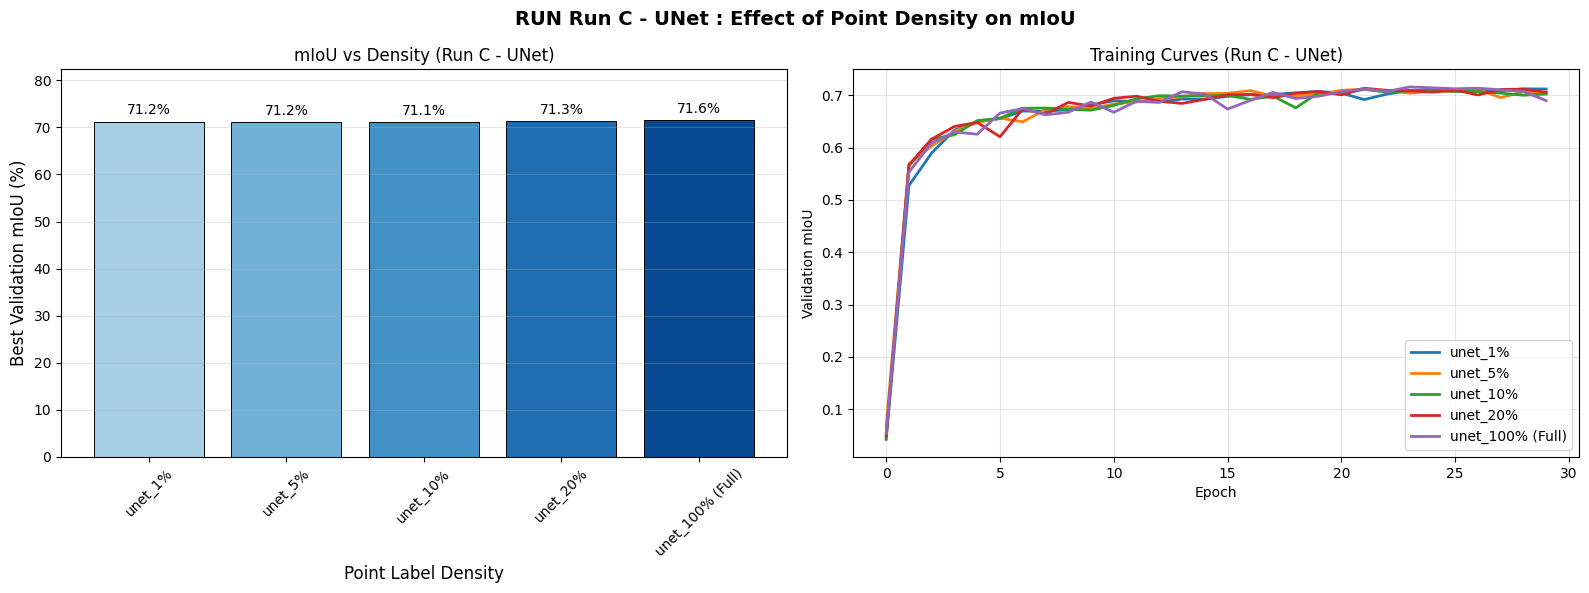

In [66]:
plot_miou_vs_density(RUN_C,
                     run_name="Run C - UNet",
                     save_path="/kaggle/working/run_c_unet_per_density.png")

### Run A vs Run B vs Run C: Architecture Comparison at 5%

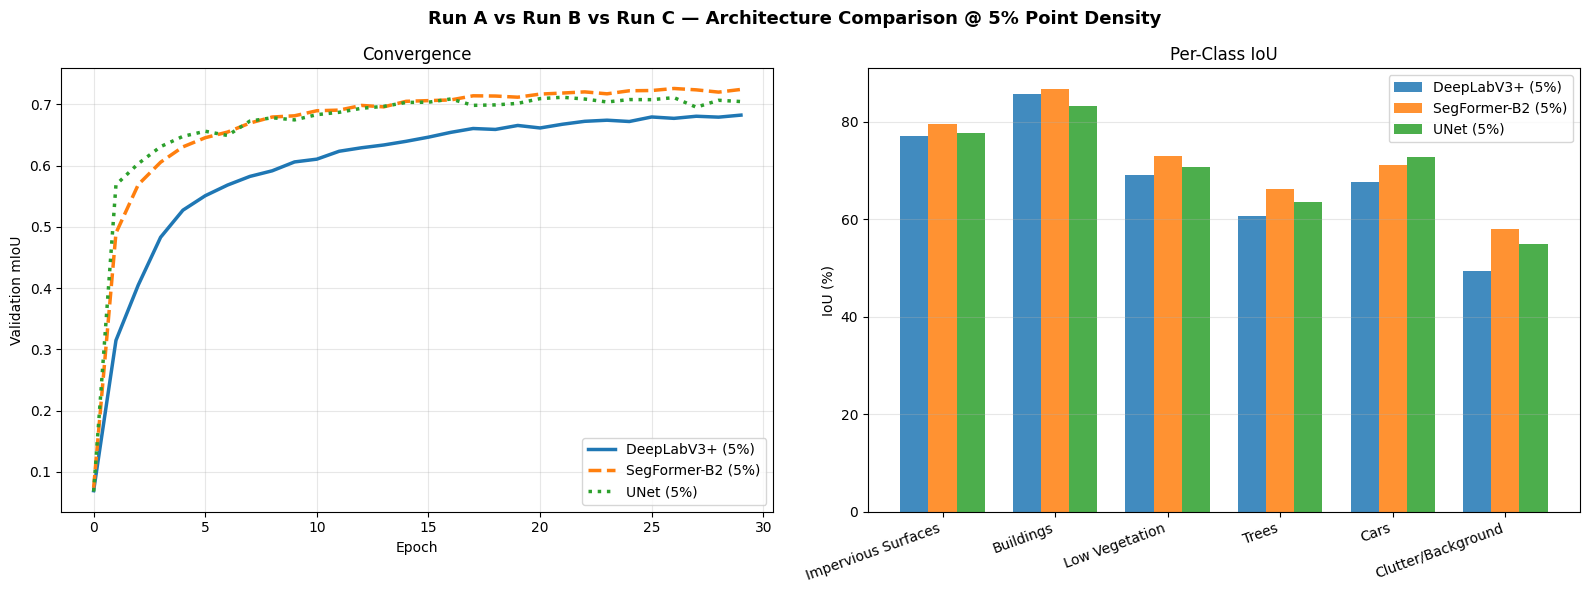

In [67]:
arch_cmp = {}
arch_cmp['DeepLabV3+ (5%)']   = dlv3_5pct
arch_cmp['SegFormer-B2 (5%)'] = sf_5pct
arch_cmp['UNet (5%)']         = unet_5pct

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Run A vs Run B vs Run C — Architecture Comparison @ 5% Point Density',
             fontsize=13, fontweight='bold')

ax = axes[0]
for (name, h), ls in zip(arch_cmp.items(), ['-', '--', ':']):
    ax.plot(h['val_miou'], label=name, linewidth=2.5, linestyle=ls)
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation mIoU')
ax.set_title('Convergence'); ax.legend(); ax.grid(alpha=0.3)

ax2 = axes[1]
x  = np.arange(NUM_CLASSES); w = 0.25
for i, (name, h) in enumerate(arch_cmp.items()):
    iou = np.array(h['final_iou_per_class']) * 100
    ax2.bar(x + (i - len(arch_cmp)/2 + 0.5)*w, iou, w, label=name, alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(CLASS_NAMES, rotation=20, ha='right', fontsize=10)
ax2.set_ylabel('IoU (%)'); ax2.set_title('Per-Class IoU'); ax2.legend(); ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/arch_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [68]:
# ─────────────────────────────────────────────────────────────────────────────
# Qualitative: Image | GT | DeepLabV3+ pred | SegFormer pred
# ─────────────────────────────────────────────────────────────────────────────
def denorm(t):
    m = torch.tensor(IMG_MEAN).view(3,1,1); s = torch.tensor(IMG_STD).view(3,1,1)
    return (t*s+m).clamp(0,1)


In [69]:
@torch.no_grad()
def qualitative_comparison(models_dict, 
                           val_loader, 
                           n=4, 
                           save_path='/kaggle/working/qualitative.png'):
    
    batch = next(iter(val_loader))
    n     = min(n, batch['image'].shape[0])  # clamp to actual batch size

    n_cols = 2 + len(models_dict)
    fig, axes = plt.subplots(n, n_cols, figsize=(4*n_cols, 4*n))
    col_titles = ['Input Image', 'Ground Truth'] + list(models_dict.keys())
    
    for c, title in enumerate(col_titles):
        axes[0, c].set_title(title, fontsize=11, fontweight='bold')

    imgs  = batch['image'][:n].to(DEVICE)
    gts   = batch['full_mask'][:n].numpy()

    for r in range(n):
        axes[r,0].imshow(denorm(imgs[r].cpu()).permute(1,2,0).numpy())
        axes[r,1].imshow(index_to_rgb(gts[r]))
        for c, (name, model) in enumerate(models_dict.items(), start=2):
            model.eval()
            out = model(imgs[r].unsqueeze(0))
            if isinstance(out, tuple): 
                out = out[0]
            axes[r,c].imshow(index_to_rgb(out.argmax(1).squeeze().cpu().numpy()))
            
        for ax in axes[r]: 
            ax.axis('off')

    patches = [mpatches.Patch(color=c, label=n_) for c,n_ in zip(CLASS_COLORS_NORM, CLASS_NAMES)]
    fig.legend(handles=patches, loc='lower center', ncol=6, fontsize=9, bbox_to_anchor=(0.5,-0.02))
    plt.tight_layout()
    plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show(); print(f'Saved: {save_path}')

In [70]:
vis_models = {}

In [71]:
m1 = DeepLabV3Plus(NUM_CLASSES).to(DEVICE)
m1.load_state_dict(torch.load(dlv3_5pct['best_ckpt'], map_location=DEVICE))
vis_models['DeepLabV3+ (5%)'] = m1

In [72]:
m2 = SegFormerB2(NUM_CLASSES).to(DEVICE)
m2.load_state_dict(torch.load(sf_5pct['best_ckpt'], map_location=DEVICE))
vis_models['SegFormer-B2 (5%)'] = m2

Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

In [73]:
m3 = UNet(NUM_CLASSES).to(DEVICE)
m3.load_state_dict(torch.load(unet_5pct['best_ckpt'], map_location=DEVICE))
vis_models['Unet-(ResNet-50) (5%)'] = m3

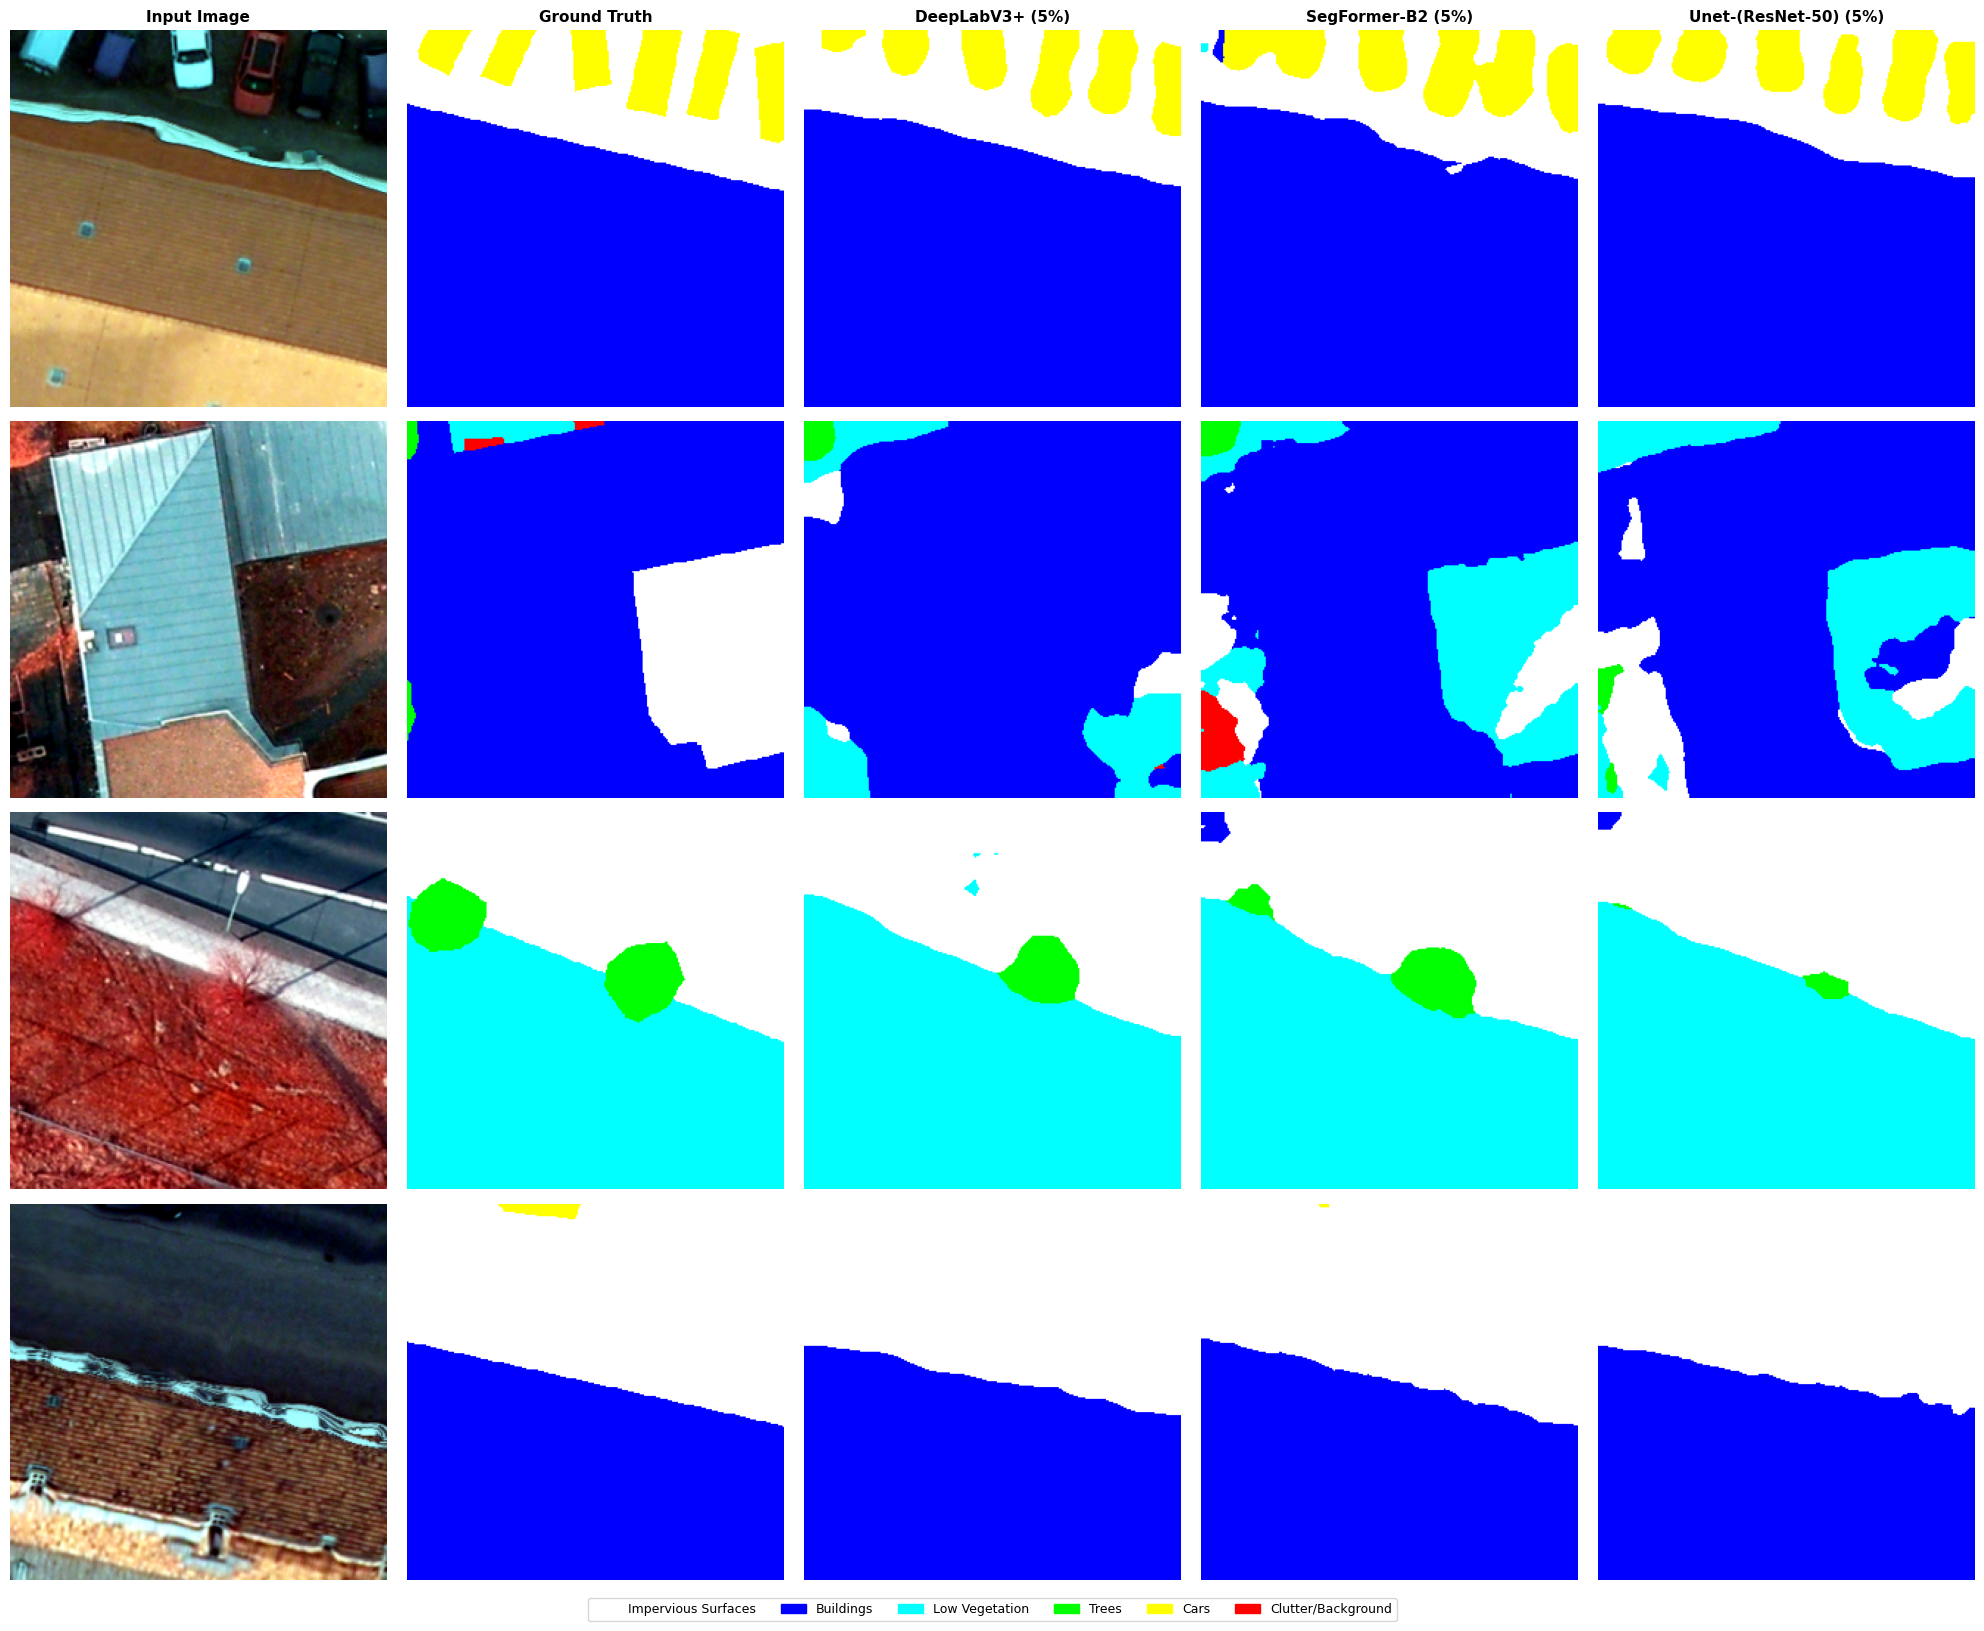

Saved: /kaggle/working/qualitative.png


In [74]:
_, val_vis_loader = make_loaders(1.0)
qualitative_comparison(vis_models, val_vis_loader)

In [75]:
DENSITIES_A = ['deeplabv3plus_1%', 'deeplabv3plus_5%', 'deeplabv3plus_10%', 'deeplabv3plus_20%', 'deeplabv3plus_100% (Full)']
DENSITIES_B = ['segformer-b2_1%',  'segformer-b2_5%',  'segformer-b2_10%',  'segformer-b2_20%',  'segformer-b2_100% (Full)']
DENSITIES_C = ['unet_1%',          'unet_5%',          'unet_10%',          'unet_20%',          'unet_100% (Full)']
LABELS      = ['1%', '5%', '10%', '20%', '100% (Full)']

dlv3_full_miou  = RUN_A['deeplabv3plus_100% (Full)']['best_miou'] * 100
segf_full_miou  = RUN_B['segformer-b2_100% (Full)']['best_miou']  * 100
unet_full_miou  = RUN_C['unet_100% (Full)']['best_miou']          * 100

print('=' * 80)
print('  FINAL RESULTS')
print('=' * 80)

### -------------------------------------------------------------------------------------------
### -------------------------------------------------------------------------------------------
### -------------------------------------------------------------------------------------------

print(f'\n  [RUN A] DeepLabV3+  (γ={FOCAL_GAMMA})')
print(f'  {"Density":<20} {"Best mIoU":>12} {"vs Full":>10} {"Accuracy":>12}')
print('  ' + '-' * 80)
for key, lbl in zip(DENSITIES_A, LABELS):
    h = RUN_A[key]
    m = h['best_miou'] * 100
    a = h['final_accuracy'] * 100
    print(f'  {lbl:<20} {m:>9.2f}%  {m-dlv3_full_miou:>+9.2f}pp  {a:>9.2f}%')

### -------------------------------------------------------------------------------------------
### -------------------------------------------------------------------------------------------
### -------------------------------------------------------------------------------------------

print(f'\n  [RUN B] SegFormer-B2  (γ={FOCAL_GAMMA})')
print(f'  {"Density":<20} {"Best mIoU":>12} {"vs Full":>10} {"Accuracy":>12}')
print('  ' + '-' * 80)
for key, lbl in zip(DENSITIES_B, LABELS):
    h = RUN_B[key]
    m = h['best_miou'] * 100
    a = h['final_accuracy'] * 100
    print(f'  {lbl:<20} {m:>9.2f}%  {m-segf_full_miou:>+9.2f}pp  {a:>9.2f}%')

### -------------------------------------------------------------------------------------------
### -------------------------------------------------------------------------------------------
### -------------------------------------------------------------------------------------------

print(f'\n  [RUN C] UNet (ResNet-50)  (γ={FOCAL_GAMMA})')
print(f'  {"Density":<20} {"Best mIoU":>12} {"vs Full":>10} {"Accuracy":>12}')
print('  ' + '-' * 80)
for key, lbl in zip(DENSITIES_C, LABELS):
    h = RUN_C[key]
    m = h['best_miou'] * 100
    a = h['final_accuracy'] * 100
    print(f'  {lbl:<20} {m:>9.2f}%  {m-unet_full_miou:>+9.2f}pp  {a:>9.2f}%')

### -------------------------------------------------------------------------------------------
### -------------------------------------------------------------------------------------------
### -------------------------------------------------------------------------------------------

print(f'\n  [HEAD-TO-HEAD] DeepLabV3+  vs  SegFormer-B2  vs  UNet')
print(f'  {"Density":<20} {"DeepLab mIoU":>14} {"SegFormer mIoU":>15} {"UNet mIoU":>11} {"Best":>10}')
print('  ' + '-' * 80)
for ka, kb, kc, lbl in zip(DENSITIES_A, DENSITIES_B, DENSITIES_C, LABELS):
    dl = RUN_A[ka]['best_miou'] * 100
    sf = RUN_B[kb]['best_miou'] * 100
    un = RUN_C[kc]['best_miou'] * 100
    best = max([(dl, 'DeepLab'), (sf, 'SegFormer'), (un, 'UNet')], key=lambda x: x[0])[1]
    print(f'  {lbl:<20} {dl:>11.2f}%  {sf:>11.2f}%  {un:>10.2f}%  {best:>14}')

  FINAL RESULTS

  [RUN A] DeepLabV3+  (γ=2.0)
  Density                 Best mIoU    vs Full     Accuracy
  --------------------------------------------------------------------------------
  1%                       68.02%      -0.87pp      84.15%
  5%                       68.25%      -0.65pp      84.62%
  10%                      68.84%      -0.06pp      84.80%
  20%                      68.51%      -0.39pp      84.75%
  100% (Full)              68.90%      +0.00pp      84.69%

  [RUN B] SegFormer-B2  (γ=2.0)
  Density                 Best mIoU    vs Full     Accuracy
  --------------------------------------------------------------------------------
  1%                       72.32%      -0.17pp      86.65%
  5%                       72.59%      +0.10pp      86.75%
  10%                      72.55%      +0.06pp      86.71%
  20%                      72.36%      -0.13pp      86.14%
  100% (Full)              72.49%      +0.00pp      86.78%

  [RUN C] UNet (ResNet-50)  (γ=2.0)
  Densi